<a href="https://colab.research.google.com/github/thesuravaram/Machine-Learning/blob/main/AdClickRatePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# Models: XGBoost vs LightGBM (with tuning)
# ============================================

# Install libraries (only if needed in Colab)
!pip install xgboost lightgbm seaborn scikit-learn



In [ ]:
# ============================================
# 1 Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve, auc
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
# ============================================
# 2️ Load Dataset
# ============================================
FILE_NAME = "ad_10000records.csv"   # already uploaded to Colab
df = pd.read_csv(FILE_NAME)
print("Dataset Loaded Successfully ✅")
print(df.head())



Dataset Loaded Successfully ✅
   Daily Time Spent on Site   Age  Area Income  Daily Internet Usage  \
0                     62.26  32.0     69481.85                172.83   
1                     41.73  31.0     61840.26                207.17   
2                     44.40  30.0     57877.15                172.83   
3                     59.88  28.0     56180.93                207.17   
4                     49.21  30.0     54324.73                201.58   

                         Ad Topic Line             City  Gender  \
0      Decentralized real-time circuit         Lisafort    Male   
1       Optional full-range projection  West Angelabury    Male   
2  Total 5thgeneration standardization        Reyesfurt  Female   
3          Balanced empowering success      New Michael  Female   
4  Total 5thgeneration standardization     West Richard  Female   

                        Country            Timestamp  Clicked on Ad  
0  Svalbard & Jan Mayen Islands  2016-06-09 21:43:05            

In [ ]:
# ============================================
# 3️ Data Preprocessing
# ============================================
print("\nChecking missing values:")
print(df.isnull().sum())

# Fill missing numeric values with mean and categorical with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])




Checking missing values:
Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Gender                      0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


/tmp/ipython-input-1416487989.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-1416487989.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  10000 non-null  float64
 1   Age                       10000 non-null  float64
 2   Area Income               10000 non-null  float64
 3   Daily Internet Usage      10000 non-null  float64
 4   Ad Topic Line             10000 non-null  int64  
 5   City                      10000 non-null  int64  
 6   Gender                    10000 non-null  int64  
 7   Country                   10000 non-null  int64  
 8   Timestamp                 10000 non-null  int64  
 9   Clicked on Ad             10000 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 781.4 KB
None


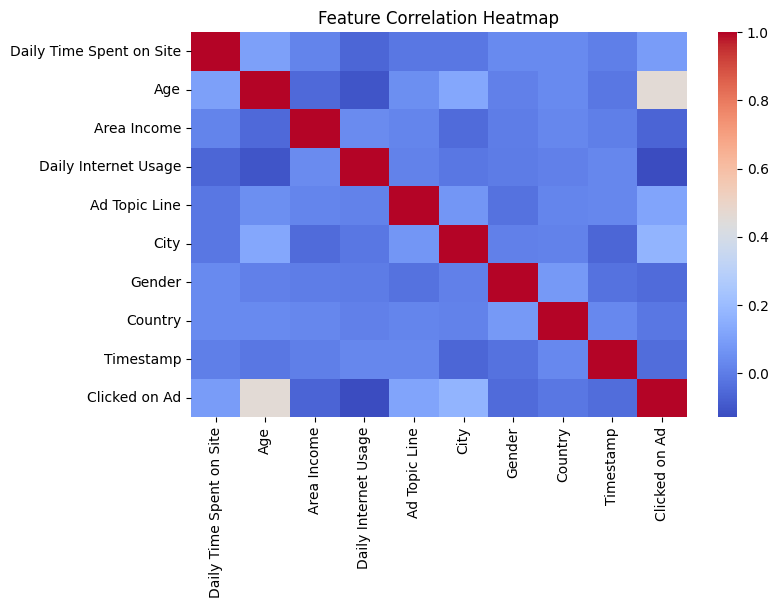

In [ ]:
# ============================================
# 4️ Exploratory Data Analysis (EDA)
# ============================================
print("\nDataset Info:")
print(df.info())

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()



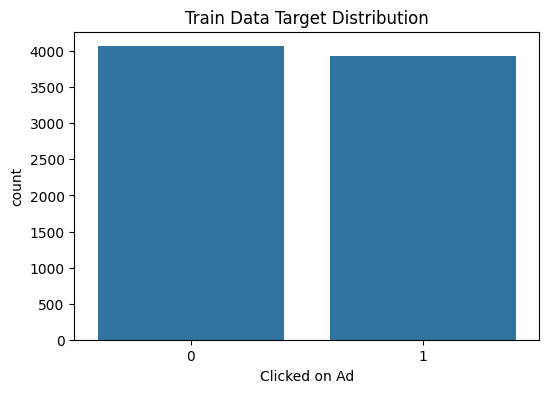

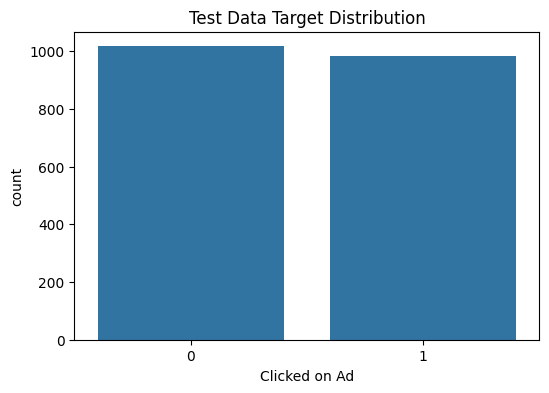

In [ ]:
# ============================================
# 5️ Define Features and Target
# ============================================
target_col = 'Clicked_on_Ad' if 'Clicked_on_Ad' in df.columns else df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Visualize train-test split
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Train Data Target Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=y_test)
plt.title("Test Data Target Distribution")
plt.show()

# Standardize numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:
# ============================================
# 6️ XGBoost Model with Hyperparameter Tuning
# ============================================
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_random = RandomizedSearchCV(
    xgb, param_distributions=param_dist_xgb,
    n_iter=5, scoring='roc_auc', cv=3, random_state=42, n_jobs=-1
)

xgb_random.fit(X_train, y_train)
xgb_best = xgb_random.best_estimator_



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:12:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# ============================================
# 7️ LightGBM Model with Hyperparameter Tuning
# ============================================
lgb = LGBMClassifier()

param_dist_lgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [-1, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'subsample': [0.7, 0.8, 1.0]
}

lgb_random = RandomizedSearchCV(
    lgb, param_distributions=param_dist_lgb,
    n_iter=5, scoring='roc_auc', cv=3, random_state=42, n_jobs=-1
)

lgb_random.fit(X_train, y_train)
lgb_best = lgb_random.best_estimator_



[LightGBM] [Info] Number of positive: 3934, number of negative: 4066
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000452 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1673
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.491750 -> initscore=-0.033003
[LightGBM] [Info] Start training from score -0.033003


In [ ]:
# ============================================
#  8 Model Evaluation Function
# ============================================
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    print(f"\n{name} Model Performance:")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc:.2f})')
    return [accuracy, precision, recall, f1, roc]




XGBoost Model Performance:
Accuracy  : 0.8175
Precision : 0.8344
Recall    : 0.7843
F1-Score  : 0.8086
ROC-AUC   : 0.9057


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Model Performance:
Accuracy  : 0.8805
Precision : 0.8727
Recall    : 0.8861
F1-Score  : 0.8794
ROC-AUC   : 0.9525


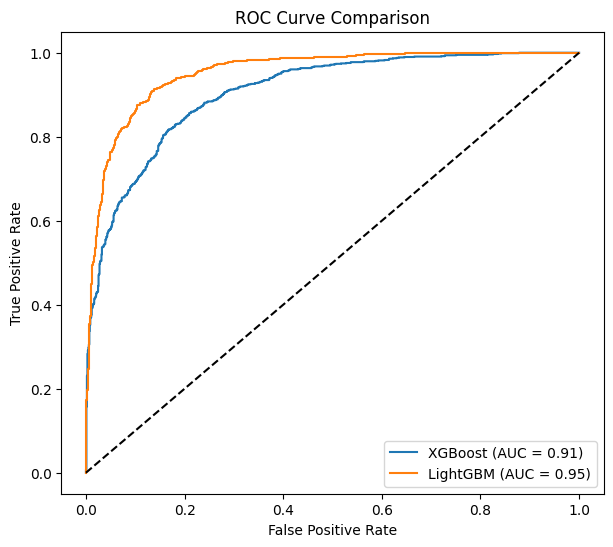

In [ ]:
# ============================================
# 9️ Compare XGBoost vs LightGBM
# ============================================
plt.figure(figsize=(7,6))
results_xgb = evaluate_model(xgb_best, X_test, y_test, "XGBoost")
results_lgb = evaluate_model(lgb_best, X_test, y_test, "LightGBM")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()




In [ ]:
# ============================================
#  10 Compare Results Summary
# ============================================
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'XGBoost': results_xgb,
    'LightGBM': results_lgb
})
print("\nModel Comparison Summary:")
display(results_df)


Model Comparison Summary:


,Metric,XGBoost,LightGBM
0,Accuracy,0.817500,0.880500
1,Precision,0.834416,0.872745
2,Recall,0.784334,0.886063
3,F1-Score,0.808600,0.879354
4,ROC-AUC,0.905711,0.952498


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['XGBoost'].plot(kind='hist', bins=20, title='XGBoost')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['LightGBM'].plot(kind='hist', bins=20, title='LightGBM')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_3.groupby('Metric').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)